# Veri Ön İşleme ve Feature Engineering
## Credit Card Fraud Detection Dataset

In [14]:
# Kütüphaneleri import et
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

---
## Phase A: Veri Yükleme ve Feature Engineering

In [15]:
# Veriyi yükle
df = pd.read_csv('Data/creditcard.csv')
print(f"Orijinal veri boyutu: {df.shape[0]:,} satır, {df.shape[1]} sütun")
df.head()

Orijinal veri boyutu: 284,807 satır, 31 sütun


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [16]:
# Feature Engineering

# 1. Time_in_day: Günlük döngü içindeki konum (saniye)
df['Time_in_day'] = df['Time'] % 86400

# 2. Amount_log: log1p(Amount)
df['Amount_log'] = np.log1p(df['Amount'])

# 3. Time_Amount: Time * Amount
df['Time_Amount'] = df['Time'] * df['Amount']

# 4. Time_Amount_sq: (Time * Amount)^2
df['Time_Amount_sq'] = (df['Time'] * df['Amount']) ** 2

# 5. Amount_per_Time: Amount / Time (Time=0 durumunda 0)
df['Amount_per_Time'] = np.where(df['Time'] == 0, 0, df['Amount'] / df['Time'])

print(f"Feature Engineering sonrası veri boyutu: {df.shape[0]:,} satır, {df.shape[1]} sütun")
print(f"\nEklenen yeni feature'lar:")
new_features = ['Time_in_day', 'Amount_log', 'Time_Amount', 'Time_Amount_sq', 'Amount_per_Time']
for f in new_features:
    print(f"  - {f}")

df[new_features].head(10)

Feature Engineering sonrası veri boyutu: 284,807 satır, 36 sütun

Eklenen yeni feature'lar:
  - Time_in_day
  - Amount_log
  - Time_Amount
  - Time_Amount_sq
  - Amount_per_Time


,Time_in_day,Amount_log,Time_Amount,Time_Amount_sq,Amount_per_Time
0,0.0,5.014760,0.00,0.0000,0.000000
1,0.0,1.305626,0.00,0.0000,0.000000
2,1.0,5.939276,378.66,143383.3956,378.660000
3,1.0,4.824306,123.50,15252.2500,123.500000
4,2.0,4.262539,139.98,19594.4004,34.995000
5,2.0,1.541159,7.34,53.8756,1.835000
6,4.0,1.790091,19.96,398.4016,1.247500
7,7.0,3.732896,285.60,81567.3600,5.828571
8,7.0,4.545420,652.40,425625.7600,13.314286
9,9.0,1.543298,33.12,1096.9344,0.408889


In [17]:
# Class sütununu category dtype'a dönüştür
df['Class'] = df['Class'].astype('category')
print(f"Class dtype: {df['Class'].dtype}")
print(f"Class categories: {df['Class'].cat.categories.tolist()}")

Class dtype: category
Class categories: [0, 1]


---
## Phase B: Train / Validation / Test Split (Stratified)

In [18]:
# Feature ve target ayır
X = df.drop('Class', axis=1)
y = df['Class'].astype(int)  # Split için int gerekli

# Stratified split: %70 Train / %15 Validation / %15 Test
# İlk split: %70 train, %30 geçici
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# İkinci split: geçici setin %50'si val, %50'si test → toplam verinin %15 / %15
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("=" * 60)
print("TRAIN / VALIDATION / TEST SPLIT")
print("=" * 60)
print(f"Train set      : {X_train.shape[0]:>7,} satır ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set : {X_val.shape[0]:>7,} satır ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set       : {X_test.shape[0]:>7,} satır ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Toplam         : {X_train.shape[0]+X_val.shape[0]+X_test.shape[0]:>7,} satır")

print(f"\nSınıf dağılımları:")
for name, ys in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    fraud = ys.sum()
    total = len(ys)
    print(f"  {name:>12s}: Normal={total-fraud:>6,}, Fraud={fraud:>4,}  (Fraud %{fraud/total*100:.4f})")

TRAIN / VALIDATION / TEST SPLIT
Train set      : 199,364 satır (70.0%)
Validation set :  42,721 satır (15.0%)
Test set       :  42,722 satır (15.0%)
Toplam         : 284,807 satır

Sınıf dağılımları:
         Train: Normal=199,020, Fraud= 344  (Fraud %0.1725)
    Validation: Normal=42,647, Fraud=  74  (Fraud %0.1732)
          Test: Normal=42,648, Fraud=  74  (Fraud %0.1732)


---
## Phase C: Standardizasyon
Amount ve Time sütunlarını (ve yeni türetilen feature'ları) StandardScaler ile standartlaştır.  
V1-V28 zaten PCA'lı — dokunulmaz.  
Scaler train üzerinde fit edilir, val ve test'e sadece transform uygulanır (data leakage önlenmesi).

In [19]:
# Standartlaştırılacak sütunlar (Amount, Time ve yeni feature'lar)
cols_to_scale = ['Amount', 'Time', 'Time_in_day', 'Amount_log',
                 'Time_Amount', 'Time_Amount_sq', 'Amount_per_Time']

scaler = StandardScaler()

# Train üzerinde fit + transform
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Validation ve Test üzerinde sadece transform
X_val[cols_to_scale] = scaler.transform(X_val[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("Standartlaştırma tamamlandı.")
print(f"\nStandartlaştırılan sütunlar: {cols_to_scale}")
print(f"\nTrain set — standartlaştırılmış sütunların istatistikleri:")
X_train[cols_to_scale].describe().T[['mean', 'std', 'min', 'max']]

Standartlaştırma tamamlandı.

Standartlaştırılan sütunlar: ['Amount', 'Time', 'Time_in_day', 'Amount_log', 'Time_Amount', 'Time_Amount_sq', 'Amount_per_Time']

Train set — standartlaştırılmış sütunların istatistikleri:


,mean,std,min,max
Amount,1.094163e-17,1.000003,-0.349257,101.170569
Time,-1.055671e-16,1.000003,-1.998286,1.640221
Time_in_day,1.524343e-16,1.000003,-2.488921,1.619521
Amount_log,-1.405660e-16,1.000003,-1.904544,4.226854
Time_Amount,-3.881248e-17,1.000003,-0.301526,155.445909
Time_Amount_sq,1.782024e-20,1.000003,-0.018900,420.243533
Amount_per_Time,-2.895788e-18,1.000003,-0.013274,395.595311


---
## Phase D: SMOTE (Sadece Train Setine)

In [20]:
# SMOTE öncesi train sınıf dağılımı
print("=" * 50)
print("SMOTE ÖNCESİ — Train Set Sınıf Dağılımı")
print("=" * 50)
print(f"Normal (0): {(y_train == 0).sum():>7,}")
print(f"Fraud  (1): {(y_train == 1).sum():>7,}")
print(f"Oran (Normal/Fraud): {(y_train == 0).sum() / (y_train == 1).sum():.2f} : 1")

SMOTE ÖNCESİ — Train Set Sınıf Dağılımı
Normal (0): 199,020
Fraud  (1):     344
Oran (Normal/Fraud): 578.55 : 1


In [21]:
# SMOTE uygula
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("=" * 50)
print("SMOTE SONRASI — Train Set Sınıf Dağılımı")
print("=" * 50)
print(f"Normal (0): {(y_train_smote == 0).sum():>7,}")
print(f"Fraud  (1): {(y_train_smote == 1).sum():>7,}")
print(f"Oran (Normal/Fraud): {(y_train_smote == 0).sum() / (y_train_smote == 1).sum():.2f} : 1")
print(f"\nToplam satır sayısı: {len(X_train_smote):,} (önceki: {len(X_train):,})")

SMOTE SONRASI — Train Set Sınıf Dağılımı
Normal (0): 199,020
Fraud  (1): 199,020
Oran (Normal/Fraud): 1.00 : 1

Toplam satır sayısı: 398,040 (önceki: 199,364)


In [22]:
# SMOTE öncesi ve sonrası karşılaştırma — sayısal tablo
comparison_data = {
    'Durum': ['SMOTE Öncesi', 'SMOTE Öncesi', 'SMOTE Sonrası', 'SMOTE Sonrası'],
    'Sınıf': ['Normal (0)', 'Fraud (1)', 'Normal (0)', 'Fraud (1)'],
    'Adet': [
        (y_train == 0).sum(), (y_train == 1).sum(),
        (y_train_smote == 0).sum(), (y_train_smote == 1).sum()
    ]
}
comparison_df = pd.DataFrame(comparison_data)
print("=" * 50)
print("SMOTE ÖNCESİ vs SONRASI — KARŞILAŞTIRMA")
print("=" * 50)
print(comparison_df.to_string(index=False))

SMOTE ÖNCESİ vs SONRASI — KARŞILAŞTIRMA
        Durum      Sınıf   Adet
 SMOTE Öncesi Normal (0) 199020
 SMOTE Öncesi  Fraud (1)    344
SMOTE Sonrası Normal (0) 199020
SMOTE Sonrası  Fraud (1) 199020


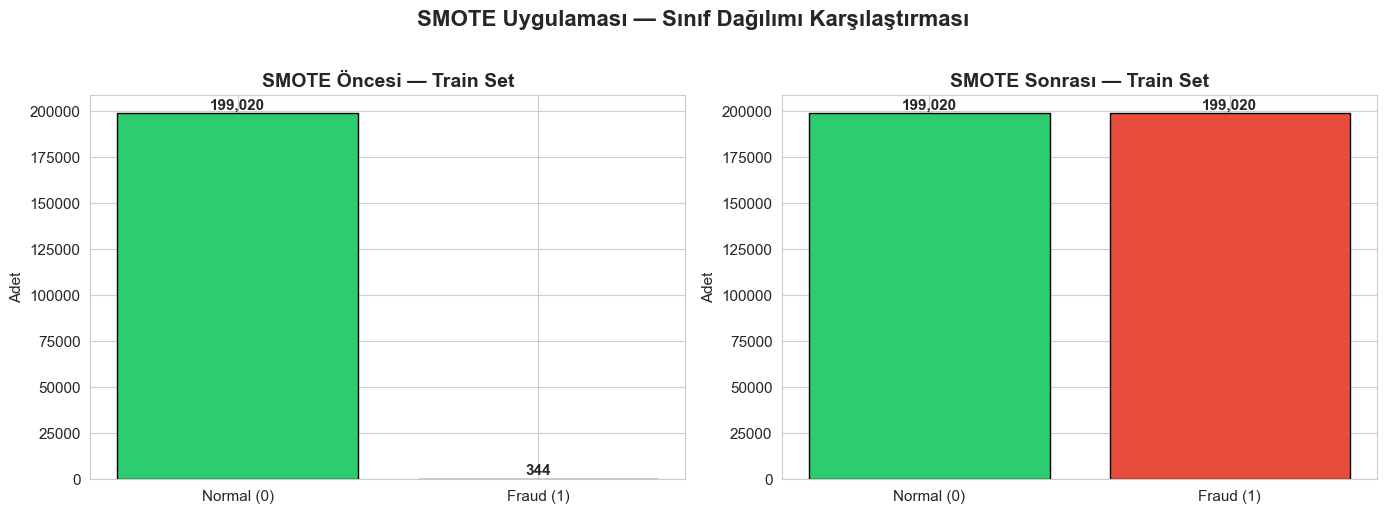

In [23]:
# SMOTE öncesi ve sonrası karşılaştırma — görsel
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#e74c3c']

# SMOTE Öncesi
before_counts = [int((y_train == 0).sum()), int((y_train == 1).sum())]
bars1 = axes[0].bar(['Normal (0)', 'Fraud (1)'], before_counts, color=colors, edgecolor='black')
axes[0].set_title('SMOTE Öncesi — Train Set', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Adet')
for bar, count in zip(bars1, before_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 500,
                f'{count:,}', ha='center', va='bottom', fontweight='bold')

# SMOTE Sonrası
after_counts = [int((y_train_smote == 0).sum()), int((y_train_smote == 1).sum())]
bars2 = axes[1].bar(['Normal (0)', 'Fraud (1)'], after_counts, color=colors, edgecolor='black')
axes[1].set_title('SMOTE Sonrası — Train Set', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Adet')
for bar, count in zip(bars2, after_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 500,
                f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('SMOTE Uygulaması — Sınıf Dağılımı Karşılaştırması',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

*Zaten hali hazırda yüksek seviyede olan veri sayımız, Smote ile dengelenince çok daha fazlalaşmıştır. Model eğitiminde fazla verinin performansı iyileştireceğini söylemek yanlış olmaz.*

---
## Phase E: Veriyi Kaydet (.parquet)

In [24]:
# data/processed/ klasörünü oluştur
os.makedirs('data/processed', exist_ok=True)

# SMOTE uygulanmış train set
train_smote_df = X_train_smote.copy()
train_smote_df['Class'] = pd.Categorical(y_train_smote)

# SMOTE uygulanmamış orijinal train set
train_original_df = X_train.copy()
train_original_df['Class'] = pd.Categorical(y_train.values)

# Validation set
val_df = X_val.copy()
val_df['Class'] = pd.Categorical(y_val.values)

# Test set
test_df = X_test.copy()
test_df['Class'] = pd.Categorical(y_test.values)

# Parquet olarak kaydet
train_smote_df.to_parquet('data/processed/train_smote.parquet', index=False)
train_original_df.to_parquet('data/processed/train_original.parquet', index=False)
val_df.to_parquet('data/processed/val.parquet', index=False)
test_df.to_parquet('data/processed/test.parquet', index=False)

print("=" * 60)
print("VERİ KAYDETME TAMAMLANDI")
print("=" * 60)
for fname in ['train_smote.parquet', 'train_original.parquet', 'val.parquet', 'test.parquet']:
    fpath = f'data/processed/{fname}'
    size_mb = os.path.getsize(fpath) / (1024 * 1024)
    tmp = pd.read_parquet(fpath)
    print(f"  {fname:<25s}: {tmp.shape[0]:>7,} satır, {tmp.shape[1]:>3} sütun, {size_mb:.2f} MB")

VERİ KAYDETME TAMAMLANDI
  train_smote.parquet      : 398,040 satır,  36 sütun, 112.07 MB
  train_original.parquet   : 199,364 satır,  36 sütun, 58.75 MB
  val.parquet              :  42,721 satır,  36 sütun, 13.56 MB
  test.parquet             :  42,722 satır,  36 sütun, 13.55 MB


In [25]:
# Doğrulama: Parquet dosyalarını oku ve kontrol et
print("=" * 60)
print("DOĞRULAMA — Parquet Dosya Kontrolleri")
print("=" * 60)

for fname in ['train_smote.parquet', 'train_original.parquet', 'val.parquet', 'test.parquet']:
    tmp = pd.read_parquet(f'data/processed/{fname}')
    print(f"\n--- {fname} ---")
    print(f"  Shape: {tmp.shape}")
    print(f"  Class dtype: {tmp['Class'].dtype}")
    print(f"  Class dağılımı: {dict(tmp['Class'].value_counts())}")
    print(f"  Sütunlar: {tmp.columns.tolist()[:5]}... (toplam {len(tmp.columns)})")

DOĞRULAMA — Parquet Dosya Kontrolleri

--- train_smote.parquet ---
  Shape: (398040, 36)
  Class dtype: int64
  Class dağılımı: {0: np.int64(199020), 1: np.int64(199020)}
  Sütunlar: ['Time', 'V1', 'V2', 'V3', 'V4']... (toplam 36)

--- train_original.parquet ---
  Shape: (199364, 36)
  Class dtype: int64
  Class dağılımı: {0: np.int64(199020), 1: np.int64(344)}
  Sütunlar: ['Time', 'V1', 'V2', 'V3', 'V4']... (toplam 36)

--- val.parquet ---
  Shape: (42721, 36)
  Class dtype: int64
  Class dağılımı: {0: np.int64(42647), 1: np.int64(74)}
  Sütunlar: ['Time', 'V1', 'V2', 'V3', 'V4']... (toplam 36)

--- test.parquet ---
  Shape: (42722, 36)
  Class dtype: int64
  Class dağılımı: {0: np.int64(42648), 1: np.int64(74)}
  Sütunlar: ['Time', 'V1', 'V2', 'V3', 'V4']... (toplam 36)


---
## Preprocessing Tamamlandı

**Çıktılar:**
- `data/processed/train_smote.parquet` — SMOTE uygulanmış train seti
- `data/processed/train_original.parquet` — Orijinal (SMOTE uygulanmamış) train seti
- `data/processed/val.parquet` — Validation seti
- `data/processed/test.parquet` — Test seti

**Uygulanan adımlar:**
1. Feature Engineering (Time_in_day, Amount_log, Time_Amount, Time_Amount_sq, Amount_per_Time)
2. Class → category dtype
3. Stratified Split (%70/%15/%15)
4. StandardScaler (Amount, Time ve yeni feature'lar — train üzerinde fit)
5. SMOTE (sadece train setine)